In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from tqdm.auto import tqdm
from utils.process_data import process_data, save_dataset

tqdm.pandas()
sns.set_style('whitegrid')

d:\viet_summarizer\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset("ithieund/VietNews-Abs-Sum")

Repo card metadata block was not found. Setting CardData to empty.


In [3]:
train_df = pd.DataFrame(dataset['train'])

In [4]:
train_df.head()

,guid,title,abstract,article
0,1,Khởi_tố kẻ_trộm hơn 1 tạ thóc và hơn 8 triệu đ...,"Với bản_tính ham chơi , lười làm , có nhiều ti...","Ngày 27/3 , Cơ_quan Cảnh_sát điều_tra Công_an ..."
1,2,Chặn_đứng 2 nhóm giang_hồ mang hung_khí hỗn_ch...,"Mâu_thuẫn từ trước đó , 2 nhóm thanh_niên với ...","VTC News đưa tin , khoảng 13h ngày 31/7 , nhận..."
2,3,"Tạm giữ hai đối_tượng tháo ốc , sắt trên đường...","Để có tiền mua ma_tuý , tiêu_xài cá_nhân , Nhậ...","Ngày 25/7 , đại_diện Công_an TP. Biên_Hoà ( tỉ..."
3,4,Tạm giam 4 tháng nữ đồng_nghiệp đâm chết nam t...,"Trong lúc nói_chuyện , Hậu đã tức_giận cầm con...","Sáng 21/2 , thông_tin từ cơ_quan CSĐT Công_an ..."
4,5,"Xế hộp tiền tỷ bỗng_dưng "" bốc_hơi "" tại chung...","Xuống nhà_xe chung_cư Hà_Đô lấy xe , một người...","Theo báo Sài_Gòn Giải_Phóng , ngày 17/3 , Công..."


### Dữ liệu trước khi xử lý

In [5]:
train_df['artical_len'] = train_df['article'].apply(lambda x: len(x.split()))
train_df['abtract_len'] = train_df['abstract'].apply(lambda x: len(x.split()))
print('Thống kê độ dài của tập Train dựa trên token đã tách):')
print(train_df[['artical_len', 'abtract_len']].describe(percentiles=[0.75, 0.9, 0.95, 0.99]))

Thống kê độ dài của tập Train dựa trên token đã tách):
         artical_len    abtract_len
count  303686.000000  303686.000000
mean      457.880455      31.279740
std       244.178084      10.200648
min        26.000000       7.000000
50%       393.000000      30.000000
75%       586.000000      37.000000
90%       806.000000      45.000000
95%       942.000000      50.000000
99%      1210.000000      62.000000
max      2897.000000     159.000000


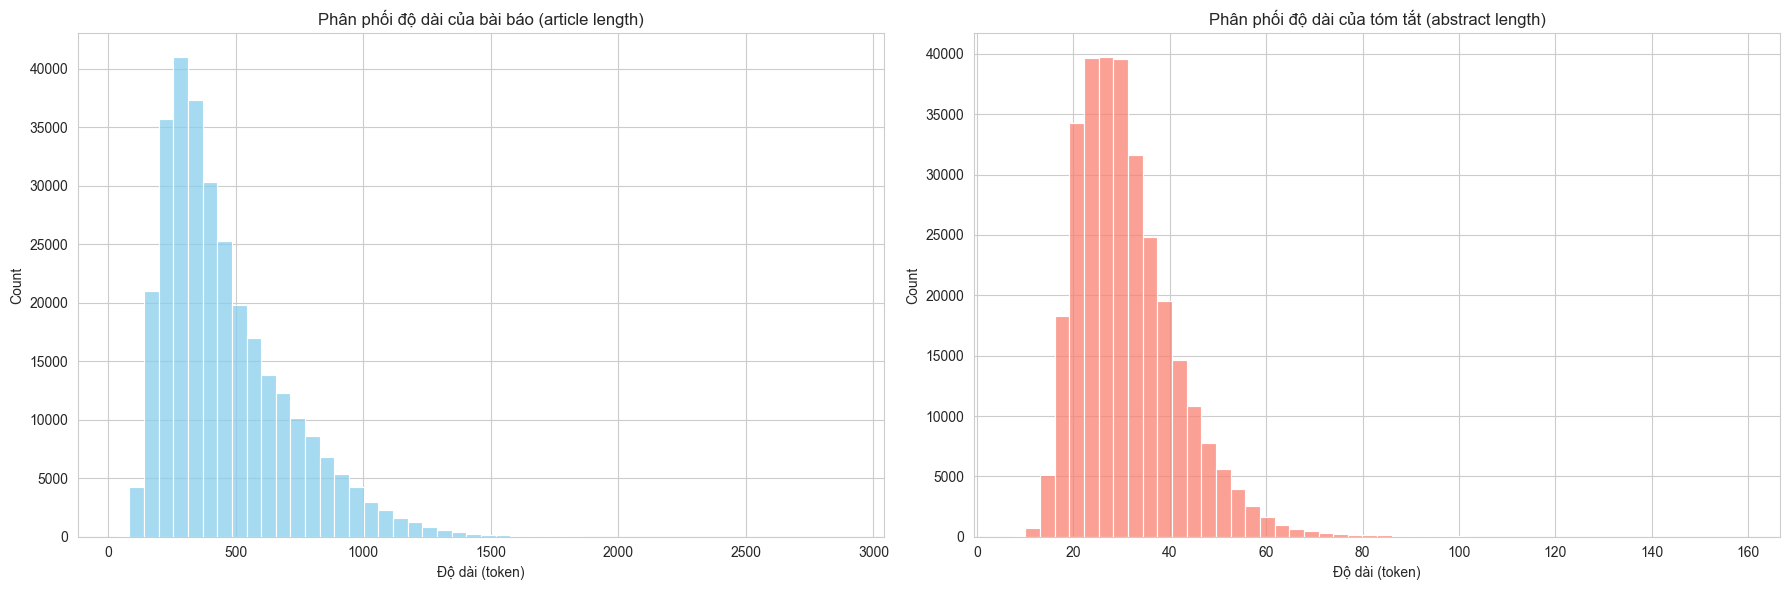

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(train_df['artical_len'], ax=axes[0], bins=50, color='skyblue')
axes[0].set_title("Phân phối độ dài của bài báo (article length)")
axes[0].set_xlabel("Độ dài (token)")


sns.histplot(train_df['abtract_len'], ax=axes[1], bins=50, color='salmon')
axes[1].set_title("Phân phối độ dài của tóm tắt (abstract length)")
axes[1].set_xlabel("Độ dài (token)")

plt.tight_layout()
plt.show()

### Xử lý dữ liệu

In [7]:
norm_train_df = process_data(dataset['train'])
norm_val_df = process_data(dataset['validation'])
norm_test_df = process_data(dataset['test'])

100%|██████████| 67640/67640 [00:02<00:00, 25288.29it/s]


### Dữ liệu sau khi đã xử lý

In [8]:
norm_train_df.head()

,guid,title,abstract,article,article_len,abstract_len
0,1,Khởi_tố kẻ_trộm hơn 1 tạ thóc và hơn 8 triệu đ...,"với bản_tính ham chơi , lười làm , có nhiều ti...","ngày 27/3 , cơ_quan cảnh_sát điều_tra công_an ...",290,39
1,2,Chặn_đứng 2 nhóm giang_hồ mang hung_khí hỗn_ch...,"mâu_thuẫn từ trước đó , 2 nhóm thanh_niên với ...","vtc news đưa tin , khoảng 13h ngày 31/7 , nhận...",180,38
2,3,"Tạm giữ hai đối_tượng tháo ốc , sắt trên đường...","để có tiền mua ma_tuý , tiêu_xài cá_nhân , nhậ...","ngày 25/7 , đại_diện công_an tp . biên_hoà ( t...",241,28
3,4,Tạm giam 4 tháng nữ đồng_nghiệp đâm chết nam t...,"trong lúc nói_chuyện , hậu đã tức_giận cầm con...","sáng 21/2 , thông_tin từ cơ_quan csđt công_an ...",342,25
4,5,"Xế hộp tiền tỷ bỗng_dưng "" bốc_hơi "" tại chung...","xuống nhà_xe chung_cư hà_đô lấy xe , một người...","theo báo sài_gòn giải_phóng , ngày 17/3 , công...",277,24


In [9]:
norm_train_df.columns

Index(['guid', 'title', 'abstract', 'article', 'article_len', 'abstract_len'], dtype='object')

In [10]:
print('Thống kê độ dài của tập Train dựa trên token đã tách):')
print(norm_train_df[['article_len', 'abstract_len']].describe(percentiles=[0.75, 0.9, 0.95, 0.99]))

Thống kê độ dài của tập Train dựa trên token đã tách):
         article_len   abstract_len
count  201156.000000  201156.000000
mean      467.120165      32.440941
std       249.478643      10.513920
min        53.000000      10.000000
50%       401.000000      31.000000
75%       597.000000      38.000000
90%       824.000000      47.000000
95%       965.000000      52.000000
99%      1235.000000      64.000000
max      2763.000000     157.000000


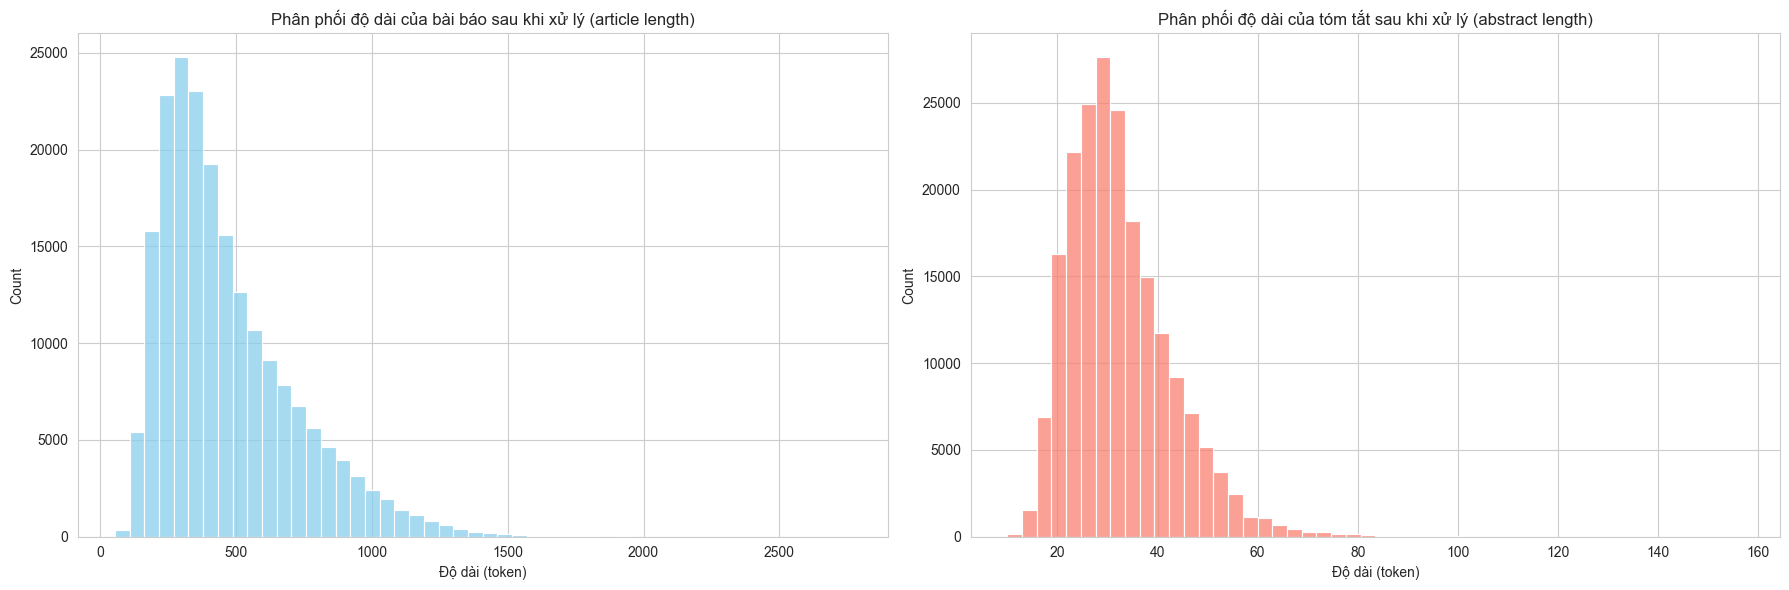

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(norm_train_df['article_len'], ax=axes[0], bins=50, color='skyblue')
axes[0].set_title("Phân phối độ dài của bài báo sau khi xử lý (article length)")
axes[0].set_xlabel("Độ dài (token)")

sns.histplot(norm_train_df['abstract_len'], ax=axes[1], bins=50, color='salmon')
axes[1].set_title("Phân phối độ dài của tóm tắt sau khi xử lý (abstract length)")
axes[1].set_xlabel("Độ dài (token)")

plt.tight_layout()
plt.show()

### Lưu dữ liệu

In [12]:
norm_train_df.drop(columns=['guid', 'title', 'article_len', 'abstract_len'], inplace=True)
norm_val_df.drop(columns=['guid', 'title', 'article_len', 'abstract_len'], inplace=True)
norm_test_df.drop(columns=['guid', 'title', 'article_len', 'abstract_len'], inplace=True)
save_dataset(norm_train_df, 'train')
save_dataset(norm_val_df, 'validation')
save_dataset(norm_test_df, 'test')

Đã lưu dữ liệu đã xử lý vào data/processed\train.csv
Đã lưu dữ liệu đã xử lý vào data/processed\validation.csv
Đã lưu dữ liệu đã xử lý vào data/processed\test.csv


### Tokenization

In [13]:
import sentencepiece as spm
sp = spm.SentencePieceProcessor()
sp.Load('tokenizers/spm_vietnamese_model.model')

True

In [ ]:
text = "Em yêu trường em với bao bạn thân và cô giáo hiền như yêu quê hương cắp sách tới trường trong muôn vàn yêu thương".lower()
ids = sp.encode(text, out_type=int)
print(ids)
print(sp.decode(ids))

In [1]:
import pandas as pd
train_df = pd.read_csv("data/processed/train.csv")
val_df = pd.read_csv("data/processed/validation.csv")
test_df = pd.read_csv("data/processed/test.csv")
print(len(train_df), len(val_df), len(test_df))

201156 44673 44990
